## Dependencies and Helper Functions

In [1]:
!pip install roboflow -q

from roboflow import Roboflow
rf = Roboflow(api_key="lsXqkr4nP217WxcbT5nC")
project = rf.workspace("computer-vision-2v7mb").project("crowd-counting-dataset-w3o7w-l8c0s")
version = project.version(1)
dataset = version.download("yolov11")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.9/276.9 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 95.7 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to crowd-counting-dataset-1 in yolov11:: 100%|██████████| 5808/5808 [00:01<00:00, 3144.22it/s]


In [2]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from PIL import Image

IMAGE_SIZE = (400, 400)
BATCH_SIZE = 30  # Reduce this if it still crashes

# ADD — replace old label_to_matrix
from scipy.ndimage import gaussian_filter

def label_to_matrix_counting(label_path, image_size=IMAGE_SIZE):
    matrix = np.zeros(image_size, dtype=np.float32)

    if os.path.getsize(label_path.numpy().decode()) == 0:
        return matrix[..., np.newaxis]

    label = pd.read_csv(label_path.numpy().decode(), sep=' ', header=None)
    points = (label[[1, 2]].values * image_size[0]).astype(int)
    points = np.clip(points, 0, image_size[0] - 1)
    matrix[points[:, 1], points[:, 0]] = 1.0

    # gaussian_filter preserves the sum, so each blob integrates to ~1
    matrix = gaussian_filter(matrix, sigma=3)

    return matrix[..., np.newaxis]


def load_sample(img_path, label_path):
    """Lazily load a single image-label pair — called per sample, not all at once."""

    # --- Image ---
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMAGE_SIZE)
    img = tf.cast(img, tf.float32) / 255.0  # (400, 400, 3)

    # --- Label matrix ---
    matrix = tf.py_function(
        func=label_to_matrix_counting,
        inp=[label_path],
        Tout=tf.float32
    )
    matrix.set_shape([*IMAGE_SIZE, 1])  # (400, 400, 1)

    return img, matrix


def make_tf_dataset(image_dir, label_dir, batch_size=BATCH_SIZE, shuffle=True):
    # Build paired file path lists
    image_files = sorted([
        f for f in os.listdir(image_dir) if f.endswith('.jpg')
    ])

    img_paths, lbl_paths = [], []
    for fname in image_files:
        lbl_fname = fname.replace('.jpg', '.txt')
        lbl_path  = os.path.join(label_dir, lbl_fname)
        if os.path.exists(lbl_path):
            img_paths.append(os.path.join(image_dir, fname))
            lbl_paths.append(lbl_path)

    print(f"Found {len(img_paths)} samples in {image_dir}")

    dataset = tf.data.Dataset.from_tensor_slices((img_paths, lbl_paths))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=200, reshuffle_each_iteration=True)

    dataset = (dataset
               .map(load_sample, num_parallel_calls=tf.data.AUTOTUNE)
               .batch(batch_size)
               .prefetch(tf.data.AUTOTUNE))

    return dataset


# --- Build datasets ---
BASE = 'crowd-counting-dataset-1'

train_ds = make_tf_dataset(f'{BASE}/train/images', f'{BASE}/train/labels', shuffle=True)
valid_ds = make_tf_dataset(f'{BASE}/valid/images', f'{BASE}/valid/labels', shuffle=False)
test_ds  = make_tf_dataset(f'{BASE}/test/images',  f'{BASE}/test/labels',  shuffle=False)

# --- Verify ---
for images, labels in train_ds.take(1):
    print("Image batch:", images.shape)   # (16, 400, 400, 3)
    print("Label batch:", labels.shape)   # (16, 400, 400, 1)

Found 2285 samples in crowd-counting-dataset-1/train/images
Found 382 samples in crowd-counting-dataset-1/valid/images
Found 231 samples in crowd-counting-dataset-1/test/images
Image batch: (30, 400, 400, 3)
Label batch: (30, 400, 400, 1)


In [3]:
def count_people(predicted_matrix, scale_factor=None):
    """
    Sum the density map to estimate crowd count.
    scale_factor calibrates the sum to actual headcount
    (computed from your training data).
    """
    total = predicted_matrix.squeeze().sum()
    if scale_factor:
        return total * scale_factor
    return total

## Testing Function

In [15]:
import time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

def evaluate_model(model, dataset, model_name="Proposed U-Net", params=217393, alpha=0.6):

    mae_list = []
    rmse_list = []
    ssim_list = []
    fps_list = []

    first = True

    for images, gt_maps in dataset:

        start = time.perf_counter()
        pred_maps = model.predict(images, verbose=0)
        elapsed = time.perf_counter() - start

        fps = images.shape[0] / elapsed
        fps_list.append(fps)

        pred_counts = np.sum(pred_maps, axis=(1,2,3))
        true_counts = np.sum(gt_maps.numpy(), axis=(1,2,3))

        # Modified MAE calculation
        mae = np.mean(np.abs(pred_counts - true_counts) / (true_counts + 1e-8)) # Added a small epsilon to prevent division by zero
        rmse = np.sqrt(np.mean((pred_counts - true_counts)**2))

        ssim = tf.reduce_mean(
            tf.image.ssim(
                gt_maps,
                pred_maps,
                max_val=1.0
            )
        ).numpy()

        mae_list.append(mae)
        rmse_list.append(rmse)
        ssim_list.append(ssim)

        # visualize only first sample
        if first:
            first = False

            img = images[0].numpy()
            pred = pred_maps[0,...,0]
            gt = gt_maps[0,...,0].numpy()

            fig, axes = plt.subplots(1,2, figsize=(12,5))

            axes[0].imshow(img)
            axes[0].imshow(pred, cmap="hot", alpha=alpha)
            axes[0].set_title(f"Predicted ({pred.sum():.1f})")
            axes[0].axis("off")

            axes[1].imshow(img)
            axes[1].imshow(gt, cmap="hot", alpha=alpha)
            axes[1].set_title(f"Ground Truth ({gt.sum():.1f})")
            axes[1].axis("off")

            plt.tight_layout()
            plt.show()

    print("| Model | Parameters | MAE ↓ | RMSE ↓ | FPS ↑ | SSIM ↑ |")
    print("|------|-----------:|------:|-------:|------:|-------:|")
    print(
        f"| {model_name} | {params:,} | "
        f"{100*np.mean(mae_list):.2f}% | " # Displaying MAE as percentage
        f"{np.mean(rmse_list):.2f} | "
        f"{np.mean(fps_list):.2f} | "
        f"{100*np.mean(ssim_list):.2f}% |"
    )

## Testing

### Our U-net model without Graph Compilation

In [16]:
MODEL_PATH = '/content/217k_relu.keras'

# Loss Function
def density_loss(
    lambda_ssim=0.2,
    lambda_count=0.05
):
    """
    Composite Density Map Loss

    Total Loss =
      MSE
      + lambda_ssim * SSIM Loss
      + lambda_count * Count Loss
    """
    def loss(y_true, y_pred):

        # -------------------------------------------------
        # 1. Pixel-wise MSE
        # -------------------------------------------------
        mse = tf.reduce_mean(
            tf.square(y_true - y_pred)
        )

        # -------------------------------------------------
        # 2. Structural Similarity Loss
        # -------------------------------------------------
        ssim = tf.image.ssim(
            tf.clip_by_value(y_true, 0., 1.),
            tf.clip_by_value(y_pred, 0., 1.),
            max_val=1.0
        )
        ssim_loss = 1.0 - tf.reduce_mean(ssim)

        # -------------------------------------------------
        # 3. Count Loss
        # Sum of density map = crowd count
        # -------------------------------------------------
        pred_count = tf.reduce_sum(y_pred, axis=[1, 2, 3])
        true_count = tf.reduce_sum(y_true, axis=[1, 2, 3])

        count_loss = tf.reduce_mean(
            tf.abs(pred_count - true_count) /
            (true_count + 1.0)
        )

        # -------------------------------------------------
        # Total Loss
        # -------------------------------------------------
        total_loss = (
            mse
            + lambda_ssim * ssim_loss
            + lambda_count * count_loss
        )

        return total_loss

    return loss

# Metrics

def pixel_mae(y_true, y_pred):
    return tf.reduce_mean(tf.abs(y_true - y_pred))


def pixel_rmse(y_true, y_pred):
    return tf.sqrt(
        tf.reduce_mean(tf.square(y_true - y_pred))
    )


def ssim_metric(y_true, y_pred):
    return tf.reduce_mean(
        tf.image.ssim(
            y_true,
            y_pred,
            max_val=1.0
        )
    )


def psnr_metric(y_true, y_pred):
    return tf.reduce_mean(
        tf.image.psnr(
            y_true,
            y_pred,
            max_val=1.0
        )
    )

def count_metric(y_true, y_pred):
    pred_count = tf.reduce_sum(y_pred, axis=[1, 2, 3])
    true_count = tf.reduce_sum(y_true, axis=[1, 2, 3])
    return tf.reduce_mean(
        tf.abs((pred_count - true_count)/(true_count+1))
    )

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"Model file not found at: {MODEL_PATH}")
unet_model = tf.keras.models.load_model(
    MODEL_PATH,
    custom_objects={'loss': density_loss(),
                    'pixel_mae': pixel_mae,
                    'pixel_rmse': pixel_rmse,
                    'ssim_metric': ssim_metric,
                    'psnr_metric': psnr_metric,
                    'count_metric': count_metric
                    }
    )

def make_inference_fn(model, image_size=(400, 400)):
    h, w = image_size
    try:
        # Attempt XLA compilation (jit_compile=True)
        @tf.function(input_signature=[tf.TensorSpec(shape=(1, h, w, 3), dtype=tf.float32)], jit_compile=True)
        def infer_jit(img_batch):
            pred = model(img_batch, training=False)
            pred = pred[0, ..., 0]
            return pred

        # Warmup and test compilation
        infer_jit(tf.zeros((1, h, w, 3), dtype=tf.float32))
        print("TF inference compiled successfully with XLA (jit_compile=True).")
        return infer_jit
    except Exception as e:
        print(f"XLA compilation failed or not supported ({e}). Falling back to standard tf.function.")
        @tf.function(input_signature=[tf.TensorSpec(shape=(1, h, w, 3), dtype=tf.float32)])
        def infer_standard(img_batch):
            pred = model(img_batch, training=False)
            pred = pred[0, ..., 0]
            return pred
        return infer_standard


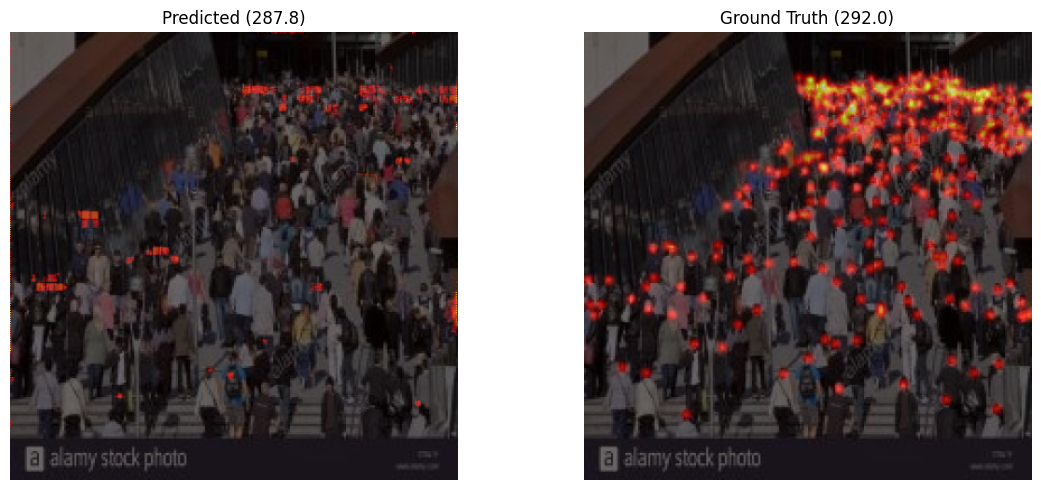

| Model | Parameters | MAE ↓ | RMSE ↓ | FPS ↑ | SSIM ↑ |
|------|-----------:|------:|-------:|------:|-------:|
| Proposed U-Net | 217,393 | 15.54% | 72.57 | 72.60 | 94.23% |


In [17]:
evaluate_model(
    unet_model,
    valid_ds,
    model_name="Proposed U-Net",
    params=217393
)

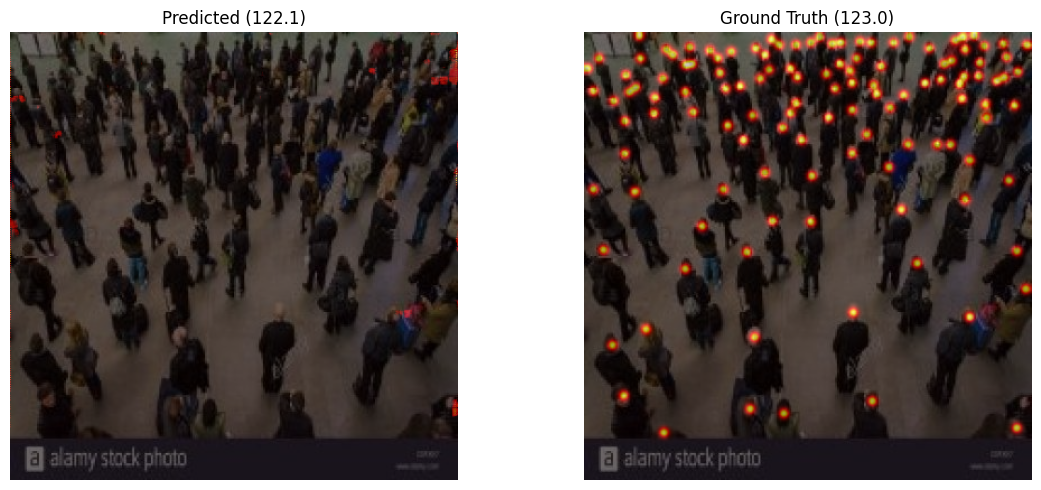

| Model | Parameters | MAE ↓ | RMSE ↓ | FPS ↑ | SSIM ↑ |
|------|-----------:|------:|-------:|------:|-------:|
| Proposed U-Net | 217,393 | 13.09% | 68.06 | 98.67 | 94.27% |


In [18]:
evaluate_model(
    unet_model,
    test_ds,
    model_name="Proposed U-Net",
    params=217393
)

### Unet Model with Graph compilation

TF inference compiled successfully with XLA (jit_compile=True).


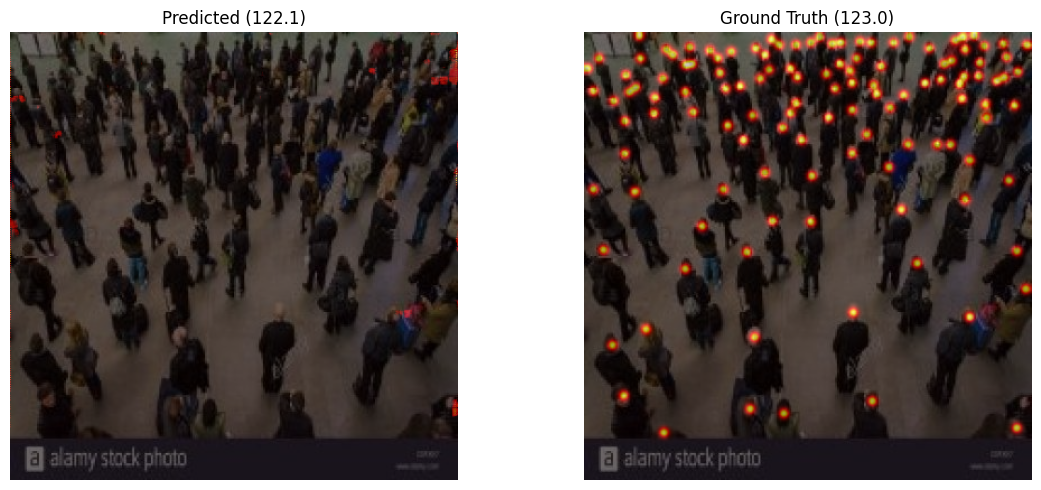

| Model | Parameters | MAE ↓ | RMSE ↓ | FPS ↑ | SSIM ↑ |
|------|-----------:|------:|-------:|------:|-------:|
| Proposed U-Net (XLA) | 217,393 | 13.09% | 68.06 | 285.50 | 94.27% |


In [19]:
infer_fn = make_inference_fn(unet_model)

def evaluate_xla_model(model_fn, dataset, model_name="Proposed U-Net (XLA)", params=217393, alpha=0.6):

    mae_list = []
    rmse_list = []
    ssim_list = []
    fps_list = []

    first = True

    for images, gt_maps in dataset:

        start = time.perf_counter()
        # Use the compiled inference function for each image in the batch
        pred_maps_list = []
        for i in range(images.shape[0]):
            img_batch_single = tf.expand_dims(images[i], axis=0)
            pred_map_single = model_fn(img_batch_single)
            # Add an extra dimension to match gt_maps shape (H, W) -> (H, W, 1)
            pred_maps_list.append(tf.expand_dims(pred_map_single, axis=-1))
        pred_maps = tf.stack(pred_maps_list, axis=0)

        elapsed = time.perf_counter() - start

        fps = images.shape[0] / elapsed
        fps_list.append(fps)

        pred_counts = np.sum(pred_maps, axis=(1,2,3))
        true_counts = np.sum(gt_maps.numpy(), axis=(1,2,3))

        # Modified MAE calculation
        mae = np.mean(np.abs(pred_counts - true_counts) / (true_counts + 1e-8)) # Added a small epsilon to prevent division by zero
        rmse = np.sqrt(np.mean((pred_counts - true_counts)**2))

        ssim = tf.reduce_mean(
            tf.image.ssim(
                gt_maps,
                pred_maps,
                max_val=1.0
            )
        ).numpy()

        mae_list.append(mae)
        rmse_list.append(rmse)
        ssim_list.append(ssim)

        # visualize only first sample
        if first:
            first = False

            img = images[0].numpy()
            pred = pred_maps[0,...,0]
            gt = gt_maps[0,...,0].numpy()

            fig, axes = plt.subplots(1,2, figsize=(12,5))

            axes[0].imshow(img)
            axes[0].imshow(pred, cmap="hot", alpha=alpha)
            axes[0].set_title(f"Predicted ({tf.reduce_sum(pred):.1f})")
            axes[0].axis("off")

            axes[1].imshow(img)
            axes[1].imshow(gt, cmap="hot", alpha=alpha)
            axes[1].set_title(f"Ground Truth ({gt.sum():.1f})")
            axes[1].axis("off")

            plt.tight_layout()
            plt.show()

    print("| Model | Parameters | MAE ↓ | RMSE ↓ | FPS ↑ | SSIM ↑ |")
    print("|------|-----------:|------:|-------:|------:|-------:|")
    print(
        f"| {model_name} | {params:,} | "
        f"{100*np.mean(mae_list):.2f}% | " # Displaying MAE as percentage
        f"{np.mean(rmse_list):.2f} | "
        f"{np.mean(fps_list):.2f} | "
        f"{100*np.mean(ssim_list):.2f}% |"
    )

evaluate_xla_model(
    infer_fn,
    test_ds,
    model_name="Proposed U-Net (XLA)",
    params=217393
)

### CSRNET Testing

In [20]:
!pip install huggingface_hub -q

from huggingface_hub import hf_hub_download

weights_path = hf_hub_download(
    repo_id="rootstrap-org/crowd-counting",   # community upload
    filename="weights.pth"
)

In [21]:
import torchvision.models as tvm
import torch
import torch.nn as nn

class CSRNet(nn.Module):
    """VGG-16 frontend + dilated conv backend."""
    def __init__(self):
        super().__init__()
        vgg = tvm.vgg16(weights=None)
        # frontend: first 10 layers of VGG (pool1–pool3 removed at end)
        self.frontend = nn.Sequential(*list(vgg.features.children())[:23])
        self.backend = nn.Sequential(
            nn.Conv2d(512, 512, 3, dilation=2, padding=2), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, 3, dilation=2, padding=2), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, 3, dilation=2, padding=2), nn.ReLU(inplace=True),
            nn.Conv2d(512, 256, 3, dilation=2, padding=2), nn.ReLU(inplace=True),
            nn.Conv2d(256, 128, 3, dilation=2, padding=2), nn.ReLU(inplace=True),
            nn.Conv2d(128,  64, 3, dilation=2, padding=2), nn.ReLU(inplace=True),
        )
        self.output_layer = nn.Conv2d(64, 1, 1) # Renamed from 'output'

    def forward(self, x):
        x = self.frontend(x)   # stride 8 relative to input
        x = self.backend(x)
        return self.output_layer(x) # Call the renamed layer


class CSRNetAdapter:
    def __init__(self, weights_path=None, device="cuda"):
        self.device = torch.device(device if torch.cuda.is_available() else "cpu")
        self.net = CSRNet().to(self.device).eval()
        if weights_path:
            self.net.load_state_dict(torch.load(weights_path, map_location=self.device))
        self.mean = torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1).to(self.device)
        self.std  = torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1).to(self.device)

    def predict(self, images, verbose=0):
        x = torch.from_numpy(images.numpy()).permute(0,3,1,2).float().to(self.device)
        x = (x - self.mean) / self.std             # ImageNet normalization
        with torch.no_grad():
            out_native = self.net(x)          # native stride-8 map, e.g. (B,1,50,50) for 400x400 input
            H, W = images.shape[1], images.shape[2]
            out_upsampled = nn.functional.interpolate(out_native, size=(H, W), mode='bilinear', align_corners=False)

            # CSRNet's published convention is to sum the density map BEFORE
            # upsampling to get the crowd count — bilinear upsampling spreads
            # each native pixel's value across ~64 output pixels without
            # preserving total mass, so summing the upsampled map inflates the
            # count by roughly that area factor. We rescale the upsampled map
            # (used for full-resolution SSIM/visualization against the
            # ground-truth map) to preserve the native, correctly-scaled sum,
            # so both the reported count and the structural comparison are
            # computed on a mass-consistent map.
            native_sum = out_native.sum(dim=[1, 2, 3], keepdim=True)
            upsampled_sum = out_upsampled.sum(dim=[1, 2, 3], keepdim=True)
            out = out_upsampled * (native_sum / (upsampled_sum + 1e-8))
        out = out.permute(0,2,3,1).cpu().numpy()
        return np.maximum(out, 0)

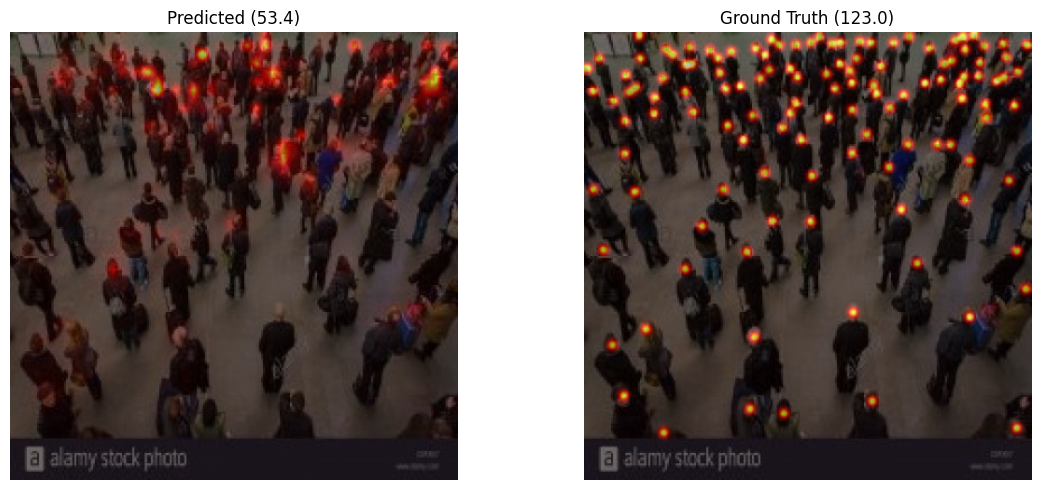

| Model | Parameters | MAE ↓ | RMSE ↓ | FPS ↑ | SSIM ↑ |
|------|-----------:|------:|-------:|------:|-------:|
| CSRNet | 17,000,000 | 48.78% | 188.80 | 23.84 | 96.25% |


In [22]:
CSRNet_model = CSRNetAdapter(weights_path=weights_path, device="cuda")

evaluate_model(
    CSRNet_model,
    test_ds,
    model_name="CSRNet",
    params=17000000
)

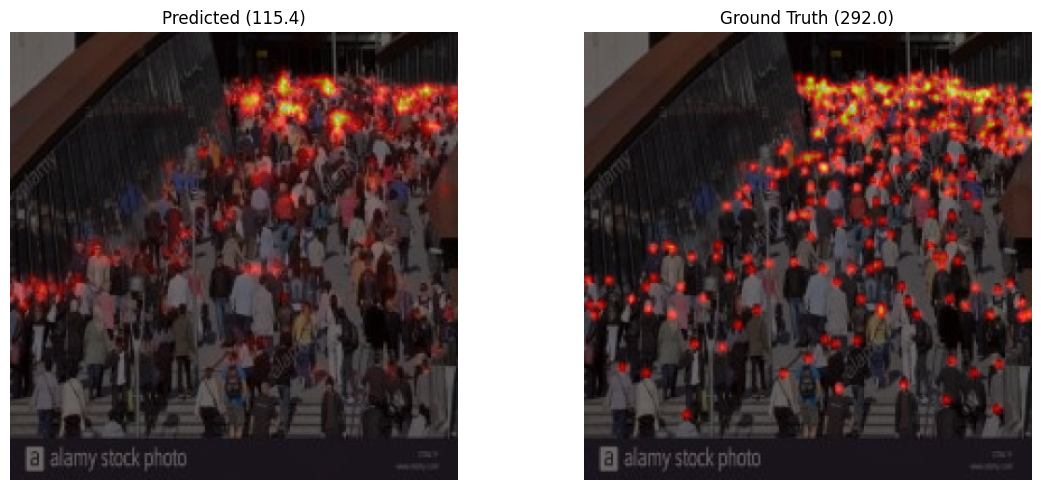

| Model | Parameters | MAE ↓ | RMSE ↓ | FPS ↑ | SSIM ↑ |
|------|-----------:|------:|-------:|------:|-------:|
| CSRNet | 17,000,000 | 47.36% | 176.58 | 24.52 | 96.31% |


In [23]:
evaluate_model(
    CSRNet_model,
    valid_ds,
    model_name="CSRNet",
    params=17000000
)